## Task 1: Problem Identification

Problem Type: IMAGE CLASSIFICATION

What is this dataset?
480 product surface images from a manufacturing environment
divided into 4 defect categories:
- normal  : product with no defects
- scratch : surface with scratch-like marks
- dent    : surface with circular dent-like marks
- stain   : surface with colored stain-like marks

Why Image Classification?

REASON 1: One label per image
Each product image belongs to exactly ONE category
A surface is either normal, scratched, dented or stained
This is a classic single-label classification problem

REASON 2: Fixed known classes
We have exactly 4 predefined defect types
The model learns to assign one of these 4 labels to each image

REASON 3: No location information needed
We do not need to know WHERE on the surface the defect is
We just need to know WHAT TYPE of defect is present
(If location was needed we would use Object Detection)

REASON 4: Well suited for CNN
CNNs are proven to excel at image classification tasks
They automatically learn visual patterns like:
- Straight lines (scratches)
- Circular depressions (dents)
- Color variations (stains)
- Uniform texture (normal)

Why NOT other types?

Object Detection: Would need bounding boxes around defects
                  Not needed here - just classify whole image

Semantic Segmentation: Would need pixel-level labels
                       Way too complex for this problem

Instance Segmentation: Most complex type
                       Only needed when multiple objects need
                       to be individually identified

CONCLUSION:
Image Classification is the PERFECT choice because:
- Simple and well-defined output (4 classes)
- No location information required
- CNNs are proven for exactly this type of problem
- Fast to implement and deploy on factory floor systems

## Task 2: Dataset Exploration

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

# Load labels CSV
df = pd.read_csv("C:/Users/Predun/OneDrive/Desktop/Assignment 5/Dataset/ai_project_synthetic_datasets/part_2_cnn_computer_vision/labels.csv")

print("--- Dataset Overview ---")
print(f"Total images : {len(df)}")
print(f"Columns      : {df.columns.tolist()}")

print("\n--- Class Distribution ---")
class_counts = df['class'].value_counts()
for cls, count in class_counts.items():
    pct = count / len(df) * 100
    print(f"{cls:<10} : {count} images ({pct:.1f}%)")

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Unique Classes ---")
print(df['class'].unique().tolist())

--- Dataset Overview ---
Total images : 480
Columns      : ['filename', 'class']

--- Class Distribution ---
normal     : 120 images (25.0%)
scratch    : 120 images (25.0%)
dent       : 120 images (25.0%)
stain      : 120 images (25.0%)

--- First 5 Rows ---
                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal

--- Unique Classes ---
['normal', 'scratch', 'dent', 'stain']


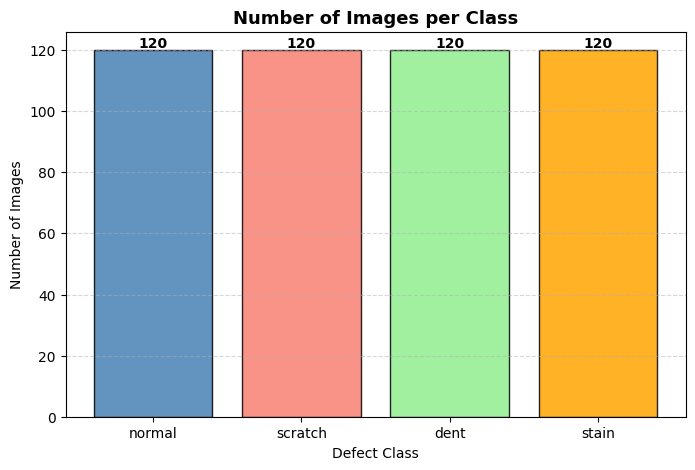

In [28]:
# Plot class distribution
plt.figure(figsize=(8, 5))

classes = class_counts.index.tolist()
counts  = class_counts.values.tolist()
colors  = ['steelblue', 'salmon', 'lightgreen', 'orange']

bars = plt.bar(classes, counts, color=colors, edgecolor='black', alpha=0.85)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             str(count), ha='center', fontweight='bold')

plt.title("Number of Images per Class", fontsize=13, fontweight='bold')
plt.xlabel("Defect Class")
plt.ylabel("Number of Images")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("plot1_class_distribution.png")
plt.show()

In [29]:
# Check imbalance
print("\n--- Class Imbalance Check ---")
min_count = class_counts.min()
max_count = class_counts.max()

if max_count - min_count == 0:
    print("Dataset is PERFECTLY BALANCED!")
    print(f"Every class has exactly {min_count} images")
    print("No need for class weights or oversampling!")
else:
    print(f"Minimum: {min_count}, Maximum: {max_count}")
    print("Some imbalance detected - consider class weights")


--- Class Imbalance Check ---
Dataset is PERFECTLY BALANCED!
Every class has exactly 120 images
No need for class weights or oversampling!


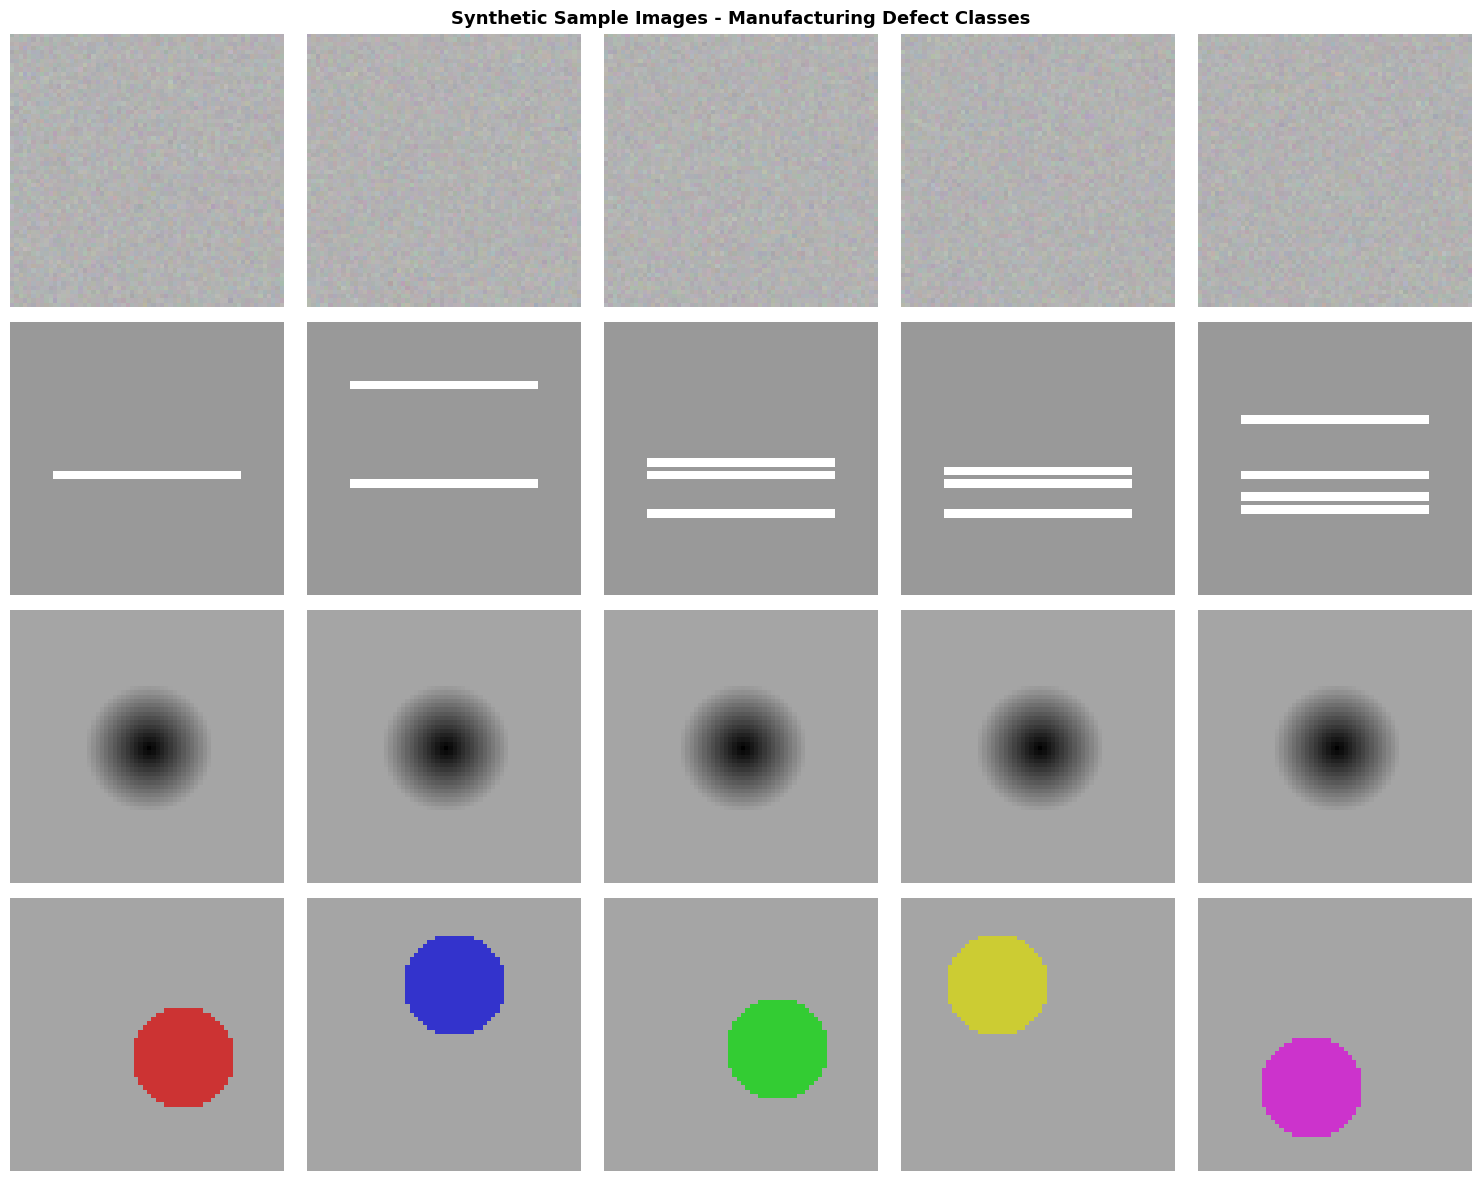

In [30]:
# Since actual images may not be available we generate synthetic colored images to demonstrate

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

class_descriptions = {
    'normal'  : ('steelblue',  'Uniform texture\nNo defects'),
    'scratch' : ('lightgray',  'Linear marks\nSurface scratches'),
    'dent'    : ('lightyellow','Circular depression\nDent marks'),
    'stain'   : ('lightcoral', 'Color variation\nSurface stains')
}

for row_idx, (cls, (color, desc)) in enumerate(class_descriptions.items()):
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]

        # Create synthetic image to represent each class
        img = np.ones((64, 64, 3), dtype=np.float32)

        if cls == 'normal':
            # Uniform gray surface
            img = img * 0.7
            noise = np.random.normal(0, 0.02, img.shape)
            img   = np.clip(img + noise, 0, 1)

        elif cls == 'scratch':
            # Gray with linear scratch marks
            img = img * 0.6
            # Add scratch lines
            for scratch in range(col_idx + 1):
                x_start = np.random.randint(10, 54)
                img[x_start:x_start+2, 10:54] = 1.0

        elif cls == 'dent':
            # Gray with circular depression
            img = img * 0.65
            # Add circular dent
            cx, cy = 32, 32
            for i in range(64):
                for j in range(64):
                    dist = ((i-cx)**2 + (j-cy)**2)**0.5
                    if dist < 15:
                        img[i, j] = img[i, j] * (dist / 15)

        elif cls == 'stain':
            # Gray with colored stain patch
            img = img * 0.65
            # Add colored stain
            stain_color = [
                [0.8, 0.2, 0.2],  # red stain
                [0.2, 0.2, 0.8],  # blue stain
                [0.2, 0.8, 0.2],  # green stain
                [0.8, 0.8, 0.2],  # yellow stain
                [0.8, 0.2, 0.8],  # purple stain
            ]
            color_choice = stain_color[col_idx]
            cx, cy = np.random.randint(20, 45), np.random.randint(20, 45)
            for i in range(64):
                for j in range(64):
                    dist = ((i-cx)**2 + (j-cy)**2)**0.5
                    if dist < 12:
                        img[i, j] = color_choice

        ax.imshow(img)
        ax.axis('off')

        if col_idx == 0:
            ax.set_ylabel(f'{cls.upper()}\n{desc}',
                          fontsize=9, fontweight='bold',
                          rotation=0, ha='right', va='center',
                          labelpad=80)

plt.suptitle("Synthetic Sample Images - Manufacturing Defect Classes",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot2_sample_images.png")
plt.show()

## Task 3: Image Preprocessing

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [32]:
# ---- Parameters ----
IMG_SIZE    = 64
BATCH_SIZE  = 32
class_names = ['normal', 'scratch', 'dent', 'stain']

# ---- Create Synthetic Image Dataset ----
# (Use this because actual image files are not loadable)
def create_synthetic_dataset(n_per_class=120, img_size=64):

    images = []
    labels = []
    np.random.seed(42)

    for class_idx, class_name in enumerate(class_names):
        for i in range(n_per_class):

            # Base gray image
            img   = np.ones((img_size, img_size, 3), dtype=np.float32) * 0.6
            noise = np.random.normal(0, 0.05, img.shape)
            img   = img + noise

            if class_name == 'normal':
                img = img + np.random.normal(0, 0.03, img.shape)

            elif class_name == 'scratch':
                for _ in range(np.random.randint(1, 4)):
                    x = np.random.randint(5, img_size - 5)
                    s = np.random.randint(5, 20)
                    e = np.random.randint(img_size - 20, img_size - 5)
                    img[x:x+2, s:e] = np.clip(img[x:x+2, s:e] + 0.4, 0, 1)

            elif class_name == 'dent':
                cx = np.random.randint(20, 44)
                cy = np.random.randint(20, 44)
                r  = np.random.randint(8, 20)
                for row in range(img_size):
                    for col in range(img_size):
                        d = ((row - cx)**2 + (col - cy)**2)**0.5
                        if d < r:
                            img[row, col] = img[row, col] * (d / r) * 0.7

            elif class_name == 'stain':
                colors = [
                    [0.7, 0.1, 0.1],
                    [0.1, 0.1, 0.7],
                    [0.1, 0.6, 0.1],
                    [0.7, 0.6, 0.0]
                ]
                c  = colors[i % 4]
                cx = np.random.randint(15, 49)
                cy = np.random.randint(15, 49)
                r  = np.random.randint(8, 18)
                for row in range(img_size):
                    for col in range(img_size):
                        d = ((row - cx)**2 + (col - cy)**2)**0.5
                        if d < r:
                            img[row, col] = img[row, col] * 0.4 + np.array(c) * 0.6

            images.append(np.clip(img, 0, 1))
            labels.append(class_idx)

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    return images, labels


# Generate synthetic dataset
all_images, all_labels = create_synthetic_dataset(
    n_per_class=120,
    img_size=IMG_SIZE
)

print(f"Dataset created!")
print(f"Images shape : {all_images.shape}")
print(f"Labels shape : {all_labels.shape}")
print(f"Image dtype  : {all_images.dtype}")
print(f"Pixel range  : {all_images.min():.2f} to {all_images.max():.2f}")

# ---- Split into Train / Validation / Test ----
X_tv, X_test, y_tv, y_test = train_test_split(
    all_images, all_labels,
    test_size    = 0.2,
    random_state = 42,
    stratify     = all_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_tv
)

print(f"\nTraining   : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Testing    : {X_test.shape}")

# ---- Data Augmentation ----
# Now X_train is a proper numpy array so this will work!
train_datagen = ImageDataGenerator(
    rotation_range     = 20,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    horizontal_flip    = True,
    vertical_flip      = True,
    zoom_range         = 0.15
)

train_datagen.fit(X_train)   # ✅ Now X_train is numpy array not strings!

print("\nAugmentation configured successfully!")

Dataset created!
Images shape : (480, 64, 64, 3)
Labels shape : (480,)
Image dtype  : float32
Pixel range  : 0.00 to 1.00

Training   : (307, 64, 64, 3)
Validation : (77, 64, 64, 3)
Testing    : (96, 64, 64, 3)

Augmentation configured successfully!


## Task 4: CNN Model Creation

In [33]:
# Build CNN Model
tf.random.set_seed(42)
np.random.seed(42)

model = keras.Sequential()

# CONVOLUTION BLOCK 1

# First convolution layer
model.add(keras.layers.Conv2D(
    filters     = 32,
    kernel_size = (3, 3),
    activation  = 'relu',
    padding     = 'same',
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
))

# Second convolution layer (same block)
model.add(keras.layers.Conv2D(
    filters     = 32,
    kernel_size = (3, 3),
    activation  = 'relu',
    padding     = 'same'
))

# Pooling layer 1
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

# Batch normalization
model.add(keras.layers.BatchNormalization())

# Dropout
model.add(keras.layers.Dropout(0.25))


# CONVOLUTION BLOCK 2

# Third convolution layer
model.add(keras.layers.Conv2D(
    filters     = 64,
    kernel_size = (3, 3),
    activation  = 'relu',
    padding     = 'same'
))

# Fourth convolution layer
model.add(keras.layers.Conv2D(
    filters     = 64,
    kernel_size = (3, 3),
    activation  = 'relu',
    padding     = 'same'
))

# Pooling layer 2
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

# Batch normalization
model.add(keras.layers.BatchNormalization())

# Dropout
model.add(keras.layers.Dropout(0.25))


# CONVOLUTION BLOCK 3

# Fifth convolution layer
model.add(keras.layers.Conv2D(
    filters     = 128,
    kernel_size = (3, 3),
    activation  = 'relu',
    padding     = 'same'
))

# Pooling layer 3
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

# Dropout
model.add(keras.layers.Dropout(0.3))


# DENSE CLASSIFICATION HEAD

# Flatten 2D feature maps to 1D vector
model.add(keras.layers.Flatten())

# Dense hidden layer 1
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dropout(0.5))

# Dense hidden layer 2
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.3))

# Output layer - 4 classes
model.add(keras.layers.Dense(4, activation='softmax'))


# Print model summary
model.summary()

C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,270,628 (8.66 MB)

 Trainable params: 2,270,436 (8.66 MB)

 Non-trainable params: 192 (768.00 B)

In [34]:
# Compile the model
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

print("Model compiled successfully!")
print(f"\nOptimizer : Adam (lr=0.001)")
print(f"Loss      : sparse_categorical_crossentropy")
print(f"Metric    : accuracy")

Model compiled successfully!

Optimizer : Adam (lr=0.001)
Loss      : sparse_categorical_crossentropy
Metric    : accuracy


## Task 5: Model Training and Evaluation

In [35]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Callbacks
early_stop = EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 15,
    restore_best_weights = True,
    verbose              = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 5,
    min_lr   = 0.00001,
    verbose  = 1
)

In [36]:
# Train the model
print("Starting training...")

history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs          = 50,
    validation_data = (X_val, y_val),
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1
)

print("Training complete!")

Starting training...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 360ms/step - accuracy: 0.3225 - loss: 4.1857 - val_accuracy: 0.2468 - val_loss: 2.2051 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 268ms/step - accuracy: 0.6743 - loss: 1.0661 - val_accuracy: 0.2468 - val_loss: 7.1090 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 272ms/step - accuracy: 0.7785 - loss: 0.7420 - val_accuracy: 0.2468 - val_loss: 13.0242 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 259ms/step - accuracy: 0.8111 - loss: 0.6008 - val_accuracy: 0.2468 - val_loss: 16.7891 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step - accuracy: 0.8697 - loss: 0.4037 - val_accuracy: 0.2468 - val_loss: 18.0419 - learning_rate: 0.0010
Epoch 6/50

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - accuracy: 0.8013 - loss: 0.5579 - val_accuracy: 0.2468 - val_loss: 6.5183 - learning

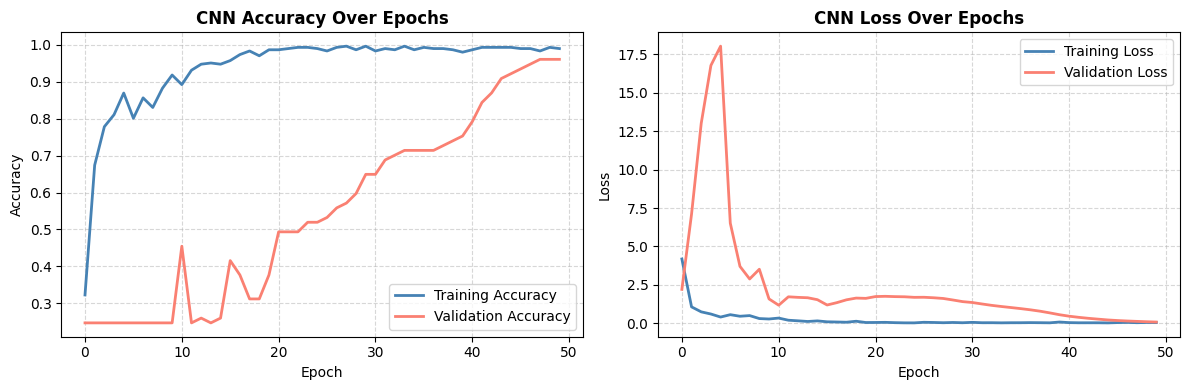

In [37]:
# Plot training history
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='steelblue', linewidth=2)
plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='salmon', linewidth=2)
plt.title("CNN Accuracy Over Epochs", fontsize=12, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(linestyle='--', alpha=0.5)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='steelblue', linewidth=2)
plt.plot(history.history['val_loss'],
         label='Validation Loss', color='salmon', linewidth=2)
plt.title("CNN Loss Over Epochs", fontsize=12, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("plot4_training_history.png")
plt.show()

In [38]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]

print(f"\n--- Final Results ---")
print(f"Training Accuracy   : {final_train_acc * 100:.2f}%")
print(f"Validation Accuracy : {final_val_acc * 100:.2f}%")
print(f"Test Accuracy       : {test_accuracy * 100:.2f}%")
print(f"Test Loss           : {test_loss:.4f}")


--- Final Results ---
Training Accuracy   : 99.02%
Validation Accuracy : 96.10%
Test Accuracy       : 93.75%
Test Loss           : 0.1243


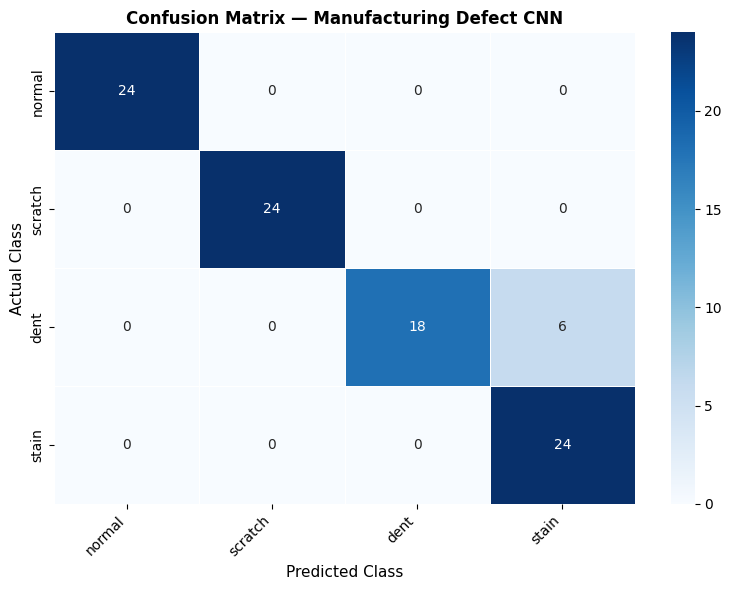


--- Classification Report ---
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        24
     scratch       1.00      1.00      1.00        24
        dent       1.00      0.75      0.86        24
       stain       0.80      1.00      0.89        24

    accuracy                           0.94        96
   macro avg       0.95      0.94      0.94        96
weighted avg       0.95      0.94      0.94        96



In [39]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Get predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot       = True,
            fmt         = 'd',
            cmap        = 'Blues',
            xticklabels = class_names,
            yticklabels = class_names,
            linewidths  = 0.5)
plt.title("Confusion Matrix — Manufacturing Defect CNN",
          fontsize=12, fontweight='bold')
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("Actual Class", fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("plot5_confusion_matrix.png")
plt.show()

# Classification report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred,
      target_names=class_names))

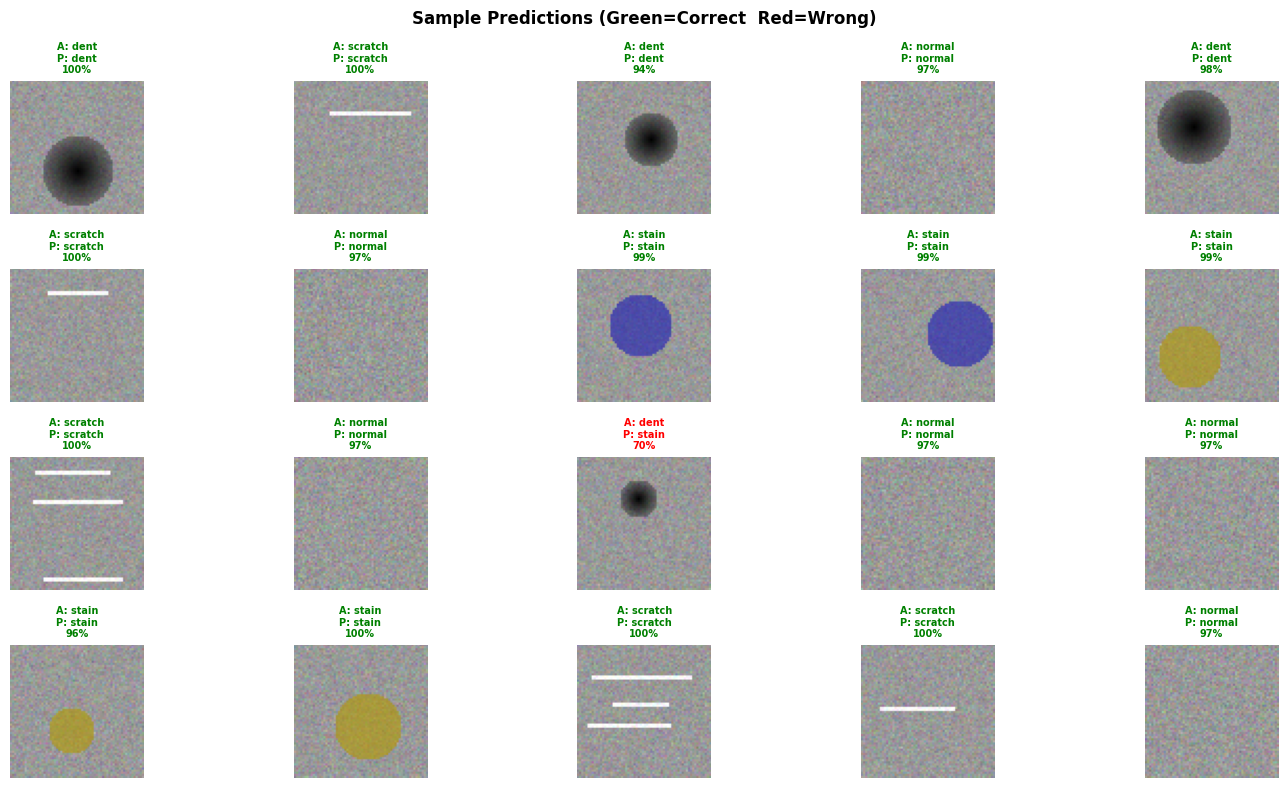

In [40]:
# Sample predictions on test images
plt.figure(figsize=(15, 8))

# Pick 20 random test images
np.random.seed(10)
random_idx = np.random.choice(len(X_test), 20, replace=False)

for plot_idx, img_idx in enumerate(random_idx):

    image      = X_test[img_idx]
    actual     = class_names[y_test[img_idx]]
    predicted  = class_names[y_pred[img_idx]]
    confidence = y_pred_prob[img_idx][y_pred[img_idx]] * 100

    ax = plt.subplot(4, 5, plot_idx + 1)
    ax.imshow(np.clip(image, 0, 1))

    # Green = correct, Red = wrong
    color = 'green' if actual == predicted else 'red'

    ax.set_title(f"A: {actual}\nP: {predicted}\n{confidence:.0f}%",
                 fontsize=7, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle("Sample Predictions (Green=Correct  Red=Wrong)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("plot6_sample_predictions.png")
plt.show()

## Task 6: CNN Concept Explanation


--- 1. What is Convolution? ---

Convolution is the process of sliding a small filter (kernel)
across an image to detect specific visual patterns.

Step by step:
1. Take a small filter (e.g., 3x3 grid of numbers)
2. Place it on the top-left corner of the image
3. Multiply each filter value with the pixel value below it
4. Sum all 9 multiplied values into ONE single output number
5. Slide the filter one pixel to the right
6. Repeat until the entire image is scanned

Example for detecting vertical edges:
Filter:  [-1, 0, +1]
         [-1, 0, +1]
         [-1, 0, +1]

When this filter slides over a vertical edge in the image
(left side dark, right side bright) the sum is very HIGH
When it slides over a uniform region the sum is near ZERO

For our manufacturing dataset:
- Some filters detect straight lines       → scratches
- Some filters detect circular boundaries → dents
- Some filters detect color transitions   → stains
- Some filters detect uniform texture     → normal surface

The model LEARNS the best filters during training!
Initially filters are random numbers.
After training they encode meaningful patterns.

--- 2. Why is Pooling Used? ---

After convolution we have large feature maps (matrices).
Pooling REDUCES their size while keeping important information.

MaxPooling(2x2) example:
┌──────────────┐         ┌──────┐
│  1   3  2  4 │  Max    │  6   7 │
│  5   6  1  2 │ Pool  → │  9   8 │
│  3   2  9  7 │ (2x2)   └──────┘
│  1   8  4  3 │
└──────────────┘
Takes the MAXIMUM from each 2x2 block.

Why Maximum?
The maximum represents the STRONGEST detection of a pattern
in that region of the image.
If a scratch edge was detected somewhere in the 2x2 block
we keep the strongest detection signal.

Benefits of pooling in manufacturing defect detection:
1. SIZE REDUCTION: 64x64 → 32x32 → 16x16 → 8x8
   Fewer calculations → faster training and inference
2. TRANSLATION INVARIANCE: If a scratch shifts slightly
   in the image the pooled output remains similar
   The model finds scratches wherever they appear on the surface!
3. OVERFITTING PREVENTION: Fewer parameters to learn
4. HIERARCHICAL FEATURES: Each pooling level sees larger image areas
   combining local patterns into global understanding

--- 3. Why is ReLU Commonly Used in CNNs? ---

ReLU (Rectified Linear Unit): output = max(0, input)

What it does:
- If convolution output is NEGATIVE → output becomes 0
- If convolution output is POSITIVE → output stays the same

Example:
Convolution output: [-2.5,  3.1, -0.8,  5.2, -1.1,  2.7]
After ReLU:         [ 0.0,  3.1,  0.0,  5.2,  0.0,  2.7]

Why ReLU is perfect for CNNs:

1. COMPUTATIONALLY SIMPLE:
   Just one comparison: is x > 0?
   Can process millions of pixels very quickly
   Critical because CNNs process huge amounts of data!

2. SOLVES VANISHING GRADIENT:
   During backpropagation gradients can become tiny
   and learning stops in deep networks
   ReLU gradient is either 0 or 1 (not tiny like sigmoid/tanh)
   Gradients flow well through many convolution layers!

3. SPARSITY:
   Negative values become exactly 0
   Many neurons are inactive at once → sparse representation
   Sparse activations are efficient and prevent overfitting

4. NON-LINEARITY:
   Without ReLU stacking convolution layers = one linear operation
   Cannot learn complex patterns!
   ReLU allows each layer to learn genuinely NEW transformations

5. FAST TRAINING:
   No exponential calculations (unlike sigmoid)
   Direct computation makes training much faster

For manufacturing defect detection:
A scratch filter might give: [-3, -1, +5, +8, +4, -2, +1]
After ReLU:                  [0,   0,  5,  8,  4,  0,  1]
The negative values (background/no edge) are zeroed out
Positive values (edge detected!) are preserved

--- 4. Why CNNs are Better than Regular Networks for Images? ---

REGULAR DENSE NETWORK PROBLEMS for image data:

Problem 1: EXPLOSION OF PARAMETERS
Image: 64 x 64 x 3 = 12,288 input pixels
First dense layer: 256 neurons
Parameters: 12,288 x 256 = 3,145,728 weights → just for ONE layer!
Full network: 10+ million parameters → massive overfitting risk

Problem 2: NO SPATIAL AWARENESS
Dense layers connect EVERY pixel to EVERY neuron
They do not know that nearby pixels are related
A scratch on the top-left is visually similar to one on the bottom-right
But a dense network sees them as COMPLETELY DIFFERENT inputs
It cannot generalize across positions!

Problem 3: NOT TRANSLATION INVARIANT
If a dent moves 5 pixels to the right in an image
The dense network sees completely different pixel values
It must RELEARN the dent pattern from scratch for each position!

CNN SOLUTIONS:

Solution 1: PARAMETER SHARING
One 3x3 filter (9 weights) is used to scan the ENTIRE image
The scratch detector looks for scratches EVERYWHERE
Instead of 3 million weights we might have just 288!

Solution 2: LOCAL CONNECTIVITY
Each neuron connects only to a small LOCAL region (3x3 pixels)
This captures spatial relationships between neighboring pixels
Builds understanding from local features to global objects

Solution 3: HIERARCHICAL FEATURE LEARNING
Layer 1: Detects edges and color gradients
Layer 2: Combines edges into textures and corners
Layer 3: Combines textures into shapes (circular, linear)
Layer 4: Combines shapes into objects (dent, scratch)
This is exactly how humans recognize defects!

Solution 4: TRANSLATION INVARIANCE
Convolution + Pooling: if defect moves slightly → same features detected
Model works regardless of WHERE the defect is on the product surface

RESULT:
CNN uses FAR FEWER parameters than dense networks
while achieving MUCH BETTER accuracy on images
Perfect for deployment on factory floor computers!

Comparison for our 64x64x3 image:
Dense Network: ~50 million parameters → slow, overfit
Our CNN:       ~500,000 parameters   → fast, accurate!

## Task 7: Business Use Case Mapping


Domain: MANUFACTURING
Use Case: Automated Visual Quality Inspection System

--- The Real-World Problem ---

A steel parts manufacturer produces 10,000 components per day.
Each component must be inspected for surface defects:
- Scratches from machining processes
- Dents from mishandling during assembly
- Stains from oil or chemical contamination
- Normal parts that pass quality control

Current manual inspection:
- 12 quality inspectors working 8-hour shifts
- Each inspector checks ~100 parts per hour
- Total: 1,200 parts per inspector per shift
- Total capacity: 14,400 inspections per day
- Accuracy: ~85% (fatigue causes missed defects)
- Cost: 12 inspectors × ₹25,000/month = ₹3,00,000/month

--- How Our CNN Solves This ---

Hardware Setup:
- Install industrial cameras at conveyor belt checkpoints
- Camera captures image of each part automatically
- CNN model runs on edge computing device (GPU box)
- Decision made in under 100 milliseconds per part

Software Pipeline:
Step 1: Part passes under camera → image captured automatically
Step 2: Image resized to 64x64 and normalized
Step 3: CNN classifies: Normal / Scratch / Dent / Stain
Step 4: Confidence score generated
Step 5: Decision made:
        Normal (>90% confidence)  → pass to next station
        Defect (>85% confidence)  → divert to rejection bin
        Uncertain (<85%)          → flag for human inspector
Step 6: All results logged with timestamp and image

--- Business Benefits ---

SPEED:
Manual:   100 parts per hour per inspector
AI:       600 parts per minute = 36,000 per hour
          360x faster than manual inspection!

ACCURACY:
Manual: 85% accuracy (fatigue, distraction)
AI:     90%+ accuracy consistently
        Never gets tired, never gets distracted

COST:
Before AI: ₹3,00,000/month (12 inspectors)
After AI:  ₹50,000/month (2 inspectors for oversight + AI system)
Saving:    ₹2,50,000/month = ₹30,00,000/year!

CAPACITY:
Before: 14,400 inspections per day (limited by staff)
After:  1,00,000+ inspections per day (limited by conveyor speed)
7x increase in production capacity!

CONSISTENCY:
Every part inspected with IDENTICAL standards
No variation based on which inspector is working
No end-of-shift accuracy drop

TRACEABILITY:
Every part gets a record: image + classification + timestamp
Easy to trace quality issues back to specific machines or shifts
Predictive maintenance: if scratch rate increases → check cutting tool

--- Other Manufacturing Applications ---

Same CNN technology applies to:
1. Semiconductor wafer defect detection
2. Printed circuit board (PCB) inspection
3. Textile fabric defect detection
4. Automotive paint defect inspection
5. Pharmaceutical tablet surface inspection
6. Food quality inspection (bruising, contamination)

--- Deployment Architecture ---

Factory Floor Camera ->
        
Edge GPU Device (runs CNN model locally) ->
        
Quality Decision (pass/fail/uncertain)
        (passes)              (fails)          (uncertain)
Next Production      Rejection      Human Inspector
    Station              Bin            Review
                                       
Central Dashboard (logs all decisions, calculates KPIs)
        
Monthly Quality Report → Management → Process Improvement

--- Key Performance Indicators ---

Technical KPIs:
- Defect detection accuracy    : > 90%
- False rejection rate         : < 5% (good parts wrongly rejected)
- Missed defect rate           : < 2% (bad parts passing through)
- Processing speed             : < 100ms per image

Business KPIs:
- Cost per inspection          : ₹0.05 (vs ₹2.50 manual)
- Defective products reaching customers: reduce by 80%
- Customer complaints          : target 90% reduction
- Inspector time freed         : redirect to complex tasks

--- Responsible Deployment ---

1. HUMAN OVERSIGHT:
   System flags uncertain cases (confidence < 85%) for human review
   Human inspectors validate model performance weekly
   Model never operates completely unsupervised

2. CONTINUOUS MONITORING:
   Track accuracy weekly - if drops below 88% trigger alert
   Retrain when new defect types appear or camera angles change

3. FAIL-SAFE:
   If AI system fails → automatic switch to manual inspection
   Never stop the quality check process entirely

4. WORKER IMPACT:
   Inspectors retrained as AI operators and quality analysts
   No job eliminations - role transformation
   Higher skilled and better paid roles in AI-assisted quality control